# ChurnGuard - Assignment II

**Group 49**

| BITS ID | Name | Contribution |
|---|---|---|
| 2025aa05877 | Vivek Kumar Aggarwal | Architecture and modularisation (100%) |
| 2025ab05013 | Nishant Choudhary | Reliability and code quality (100%) |
| 2025aa05544 | Sumanth T P | API and deployment readiness (100%) |
| 2025aa05974 | Ravi Raj Ladha | Quality assurance and model metrics (100%) |

This notebook contains the research prototype followed by results from the production implementation in `src/churnguard`.

## 1. Research prototype

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score
%matplotlib inline

In [2]:
df = pd.read_csv("../data/raw/telco_churn.csv")  # Prototype uses a notebook-relative path.
df.head()

,customer_id,tenure_months,monthly_charges,total_charges,support_tickets_6m,avg_monthly_gb,contract_type,internet_service,payment_method,tech_support,paperless_billing,churn
0,CUST-000001,60,37.91,2262.99,1,4.0,Month-to-month,No,Mailed check,Yes,Yes,1
1,CUST-000002,38,63.57,2385.51,0,11.6,Month-to-month,Fiber optic,Credit card,Yes,Yes,0
2,CUST-000003,61,63.92,3825.53,0,30.2,Two year,DSL,Bank transfer,Yes,Yes,0
3,CUST-000004,48,81.47,4117.85,1,30.0,Month-to-month,Fiber optic,Credit card,No,Yes,0
4,CUST-000005,7,59.85,426.08,0,18.2,One year,DSL,Electronic check,No,No,1


In [3]:
df.shape, df.churn.mean()

((5000, 12), np.float64(0.2666))

In [4]:
df.isnull().sum()

customer_id            0
tenure_months          0
monthly_charges        0
total_charges         60
support_tickets_6m     0
avg_monthly_gb        30
contract_type          0
internet_service       0
payment_method         0
tech_support           0
paperless_billing      0
churn                  0
dtype: int64

In [5]:
# Prototype shortcut: replace all missing values with zero.
df = df.fillna(0)

In [6]:
# Expand categorical columns for the standalone prototype model.
X = pd.get_dummies(df.drop(['churn', 'customer_id'], axis=1))
y = df.churn

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)  # Prototype does not fix a seed.

In [8]:
m = RandomForestClassifier(n_estimators=100)
m.fit(X_train, y_train)
p = m.predict_proba(X_test)[:, 1]
print(accuracy_score(y_test, m.predict(X_test)))
print(roc_auc_score(y_test, p))

0.773
0.7848826666666667


In [9]:
# Evaluate a derived spend-per-month feature.
X_train['spm'] = X_train.total_charges / X_train.tenure_months
X_test['spm'] = X_test.total_charges / X_test.tenure_months
m.fit(X_train, y_train)
roc_auc_score(y_test, m.predict_proba(X_test)[:, 1])

0.7834293333333333

In [10]:
# Compare a depth-limited model.
m2 = RandomForestClassifier(n_estimators=100, max_depth=8)
m2.fit(X_train, y_train)
roc_auc_score(y_test, m2.predict_proba(X_test)[:, 1])

0.8029439999999999

In [11]:
import pickle

# Serialize the prototype estimator without creating an untracked file.
model_bytes = pickle.dumps(m2)
len(model_bytes)

2578261

## 2. Production implementation and evaluation

The production package keeps feature engineering, preprocessing, calibration, and classification in one pipeline. The following cells load the saved validation results and figures generated from the current model.

In [12]:
from pathlib import Path
import json
import sys

project_root = Path.cwd().resolve()
if project_root.name == 'notebooks':
    project_root = project_root.parent
sys.path.insert(0, str(project_root / 'src'))

from churnguard.data.ingestion import CsvDataSource
from churnguard.data.validation import DataValidator
from churnguard.models.trainer import ChurnModelTrainer

production_frame = CsvDataSource(project_root / 'data/raw/telco_churn.csv').load()
validation_report = DataValidator().validate(production_frame)
pipeline_steps = [name for name, _ in ChurnModelTrainer().build_pipeline().steps]
{'rows': len(production_frame), 'validation_passed': validation_report.passed, 'pipeline_steps': pipeline_steps}

DATA-QUALITY WARN | Column 'total_charges' has 1.20% nulls (imputed)


DATA-QUALITY WARN | Column 'avg_monthly_gb' has 0.60% nulls (imputed)


{'rows': 5000,
 'validation_passed': True,
 'pipeline_steps': ['features', 'preprocess', 'classifier']}

### Model and data quality metrics

The table uses the holdout metrics written by `scripts/train.py`. The configured ROC-AUC, F1, and Brier gates all pass.

In [13]:
metrics = json.loads((project_root / 'reports/model_metrics.json').read_text())
model_metrics = pd.DataFrame(
    [
        ('Accuracy', metrics['accuracy']),
        ('Precision', metrics['precision']),
        ('Recall', metrics['recall']),
        ('F1', metrics['f1']),
        ('ROC-AUC', metrics['roc_auc']),
        ('Brier score', metrics['brier']),
        ('Expected calibration error', metrics['ece']),
        ('5-fold ROC-AUC mean', metrics['cv_roc_auc_mean']),
    ],
    columns=['Metric', 'Value'],
)
model_metrics.style.format({'Value': '{:.4f}'})

,Metric,Value
0,Accuracy,0.7580
1,Precision,0.5439
2,Recall,0.5805
3,F1,0.5616
4,ROC-AUC,0.7893
5,Brier score,0.1518
6,Expected calibration error,0.0185
7,5-fold ROC-AUC mean,0.7917


In [14]:
quality = metrics['data_quality']
data_metrics = pd.DataFrame(
    [
        ('Validation passed', quality['passed']),
        ('Overall missing fraction', quality['metrics']['missing_fraction_overall']),
        ('total_charges missing', quality['metrics']['missing_fraction__total_charges']),
        ('avg_monthly_gb missing', quality['metrics']['missing_fraction__avg_monthly_gb']),
        ('Maximum PSI', max(
            value for key, value in quality['metrics'].items() if key.startswith('psi__')
        )),
    ],
    columns=['Data check', 'Value'],
)
data_metrics

,Data check,Value
0,Validation passed,True
1,Overall missing fraction,0.0018
2,total_charges missing,0.012
3,avg_monthly_gb missing,0.006
4,Maximum PSI,0.0005


### Evaluation figures

These plots show discrimination, calibration, classification errors, threshold selection, drift sensitivity, and the operational risk bands.

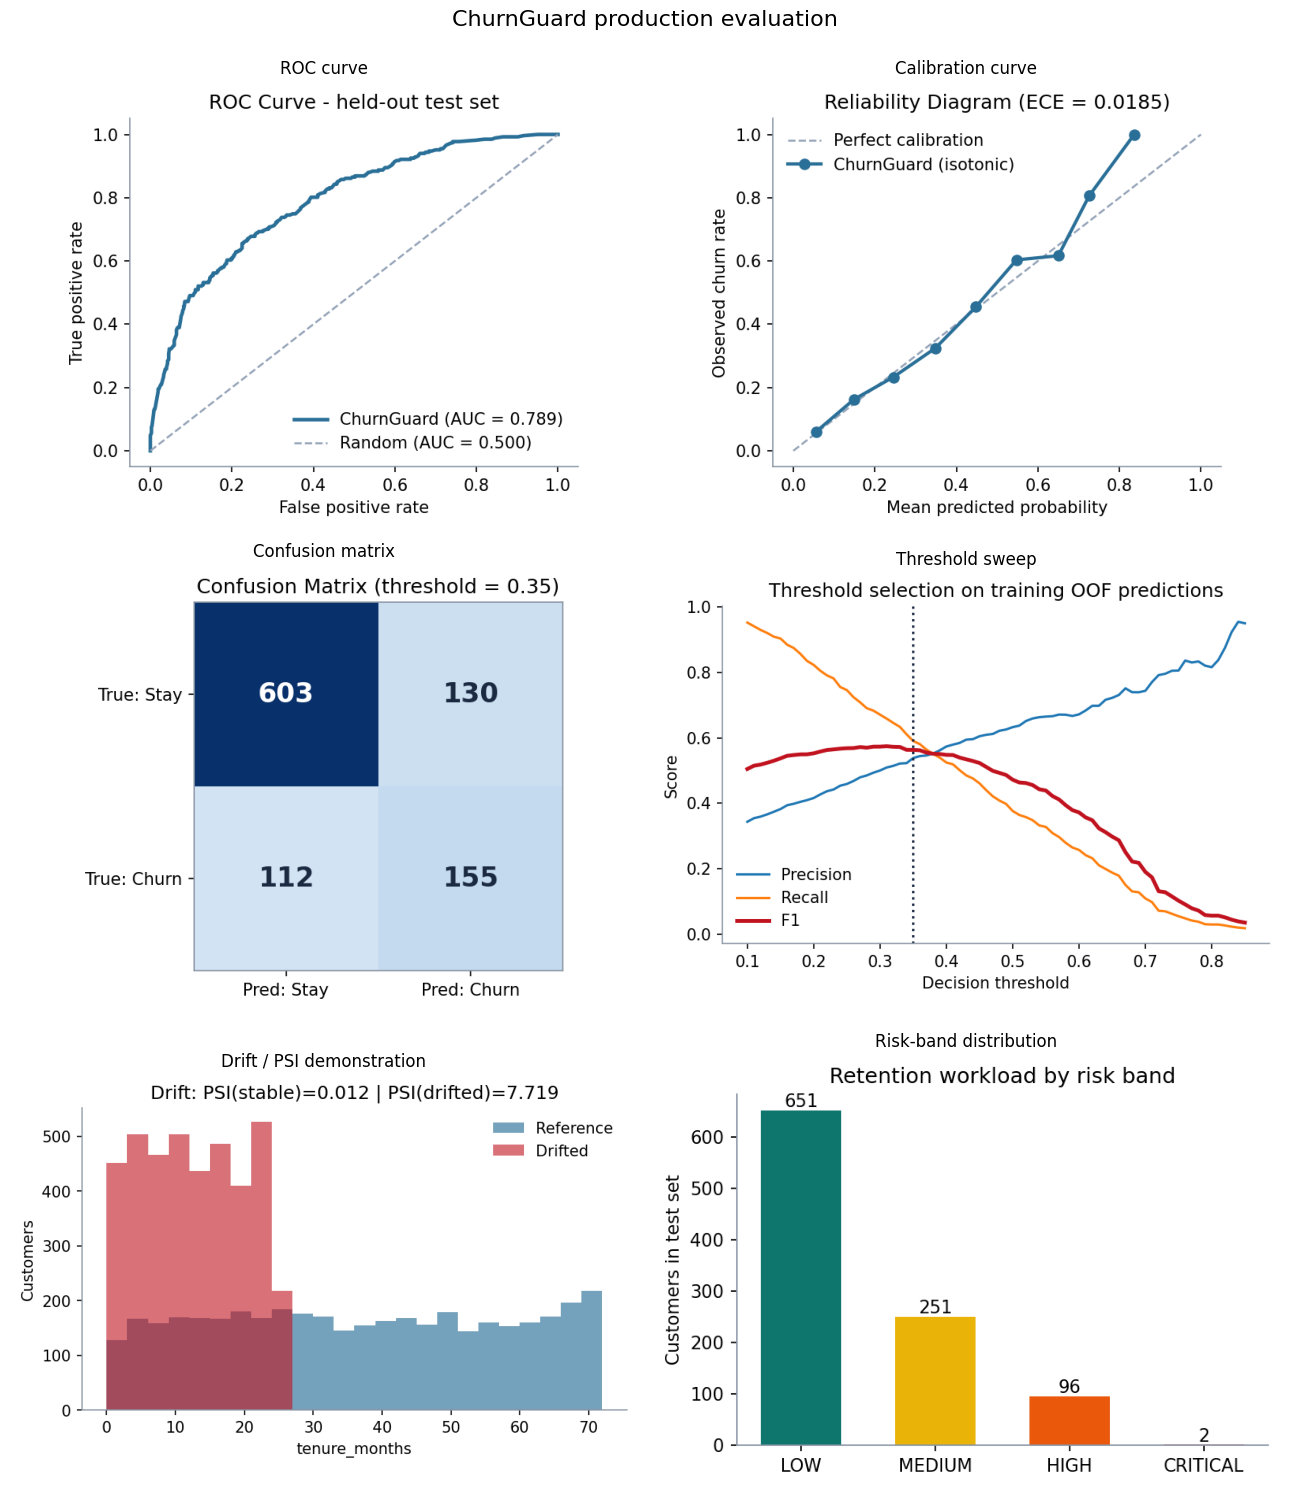

In [15]:
figure_names = [
    'roc_curve.png',
    'calibration_curve.png',
    'confusion_matrix.png',
    'threshold_sweep.png',
    'drift_psi.png',
    'risk_bands.png',
]
figure_titles = [
    'ROC curve',
    'Calibration curve',
    'Confusion matrix',
    'Threshold sweep',
    'Drift / PSI demonstration',
    'Risk-band distribution',
]

fig, axes = plt.subplots(3, 2, figsize=(13, 15))
for axis, filename, title in zip(axes.flat, figure_names, figure_titles):
    axis.imshow(plt.imread(project_root / 'reports/figures' / filename))
    axis.set_title(title, fontsize=12)
    axis.axis('off')
fig.suptitle('ChurnGuard production evaluation', fontsize=16, y=1.0)
plt.tight_layout()
plt.show()